# Notebook 4: Cartesian Impedance Control with Jacobian-Mediated Force Transmission

## From Joint Space to Task Space

In Notebook 3, we specified stiffness **in joint coordinates** — $K_1$ controls joint 1, $K_2$ controls joint 2. The end-effector position was a *consequence* of joint control.

**The question Notebook 4 answers:** What if we want to say *"I want 500 N/m stiffness in the X direction and 200 N/m in the Z direction"*?

We need to express the impedance law in Cartesian space and then **map forces back to joint torques**. The mapping is the **Jacobian transpose**:

$$\boldsymbol{\tau} = \mathbf{J}^T(\mathbf{q})\, \mathbf{F}_{cart}$$

where $\mathbf{F}_{cart} = \mathbf{K}_{cart}(\mathbf{x}_d - \mathbf{x}) + \mathbf{B}_{cart}(\dot{\mathbf{x}}_d - \dot{\mathbf{x}})$ is the desired Cartesian restoring force.

MuJoCo computes $\mathbf{J}(\mathbf{q})$ for us via `mj_jacSite`.

**What you will learn:**
1. The Jacobian transpose as the dual of velocity kinematics
2. How to compute the Jacobian using MuJoCo's `mj_jacSite` API
3. Cartesian impedance control with a circle trajectory
4. Why Cartesian control gives better end-effector tracking than joint-space control
5. Stiffness ellipses — the geometry of direction-dependent compliance

## Setup

In [3]:
import dms
import os
import tempfile
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
print(f"MuJoCo version: {mujoco.__version__}")


MuJoCo version: 3.6.0


In [5]:
# Load the same planar RR arm as Notebook 3
model_path = dms.get_asset_path('mujoco_models/planar_rr_arm.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))
data  = mujoco.MjData(model)

print(f"Degrees of freedom (nv): {model.nv}")
print(f"Actuators (nu):          {model.nu}")
print(f"Sites (nsite):           {model.nsite}")
print(f"Timestep (dt):           {model.opt.timestep} s")

Degrees of freedom (nv): 2
Actuators (nu):          2
Sites (nsite):           1
Timestep (dt):           0.001 s


In [7]:
# Resolve end-effector site ID (defined in planar_rr_arm.xml as <site name="ee" .../>)
ee_site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "ee")
print(f"ee site ID: {ee_site_id}")
assert ee_site_id >= 0, "Site 'ee' not found in model!"

# Pre-allocate Jacobian arrays outside the simulation loop
jacp = np.zeros((3, model.nv))   # translational Jacobian: shape (3, 2) for 2-DOF arm
jacr = np.zeros((3, model.nv))   # rotational Jacobian: allocate even if unused

print(f"jacp shape: {jacp.shape}  (3 world directions × {model.nv} joints)")
print(f"jacr shape: {jacr.shape}")

# Verify ee site position at default configuration (arm hanging)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)
print(f"\nEE position at default qpos={np.degrees(data.qpos[:2])} deg:")
print(f"  site_xpos[ee] = {data.site_xpos[ee_site_id]}  (world frame X, Y, Z)")

ee site ID: 0
jacp shape: (3, 2)  (3 world directions × 2 joints)
jacr shape: (3, 2)

EE position at default qpos=[0. 0.] deg:
  site_xpos[ee] = [0.7 0.  1. ]  (world frame X, Y, Z)


## Theory: Cartesian Impedance Law

### The Full Law

The Cartesian impedance law has two steps:

**Step 1: Compute desired Cartesian force** (in task space)

$$\mathbf{F}_{cart} = \mathbf{K}_{cart}(\mathbf{x}_d - \mathbf{x}) + \mathbf{B}_{cart}(\dot{\mathbf{x}}_d - \dot{\mathbf{x}})$$

where:
- $\mathbf{x} \in \mathbb{R}^2$ is the current end-effector position in the X-Z plane
- $\mathbf{x}_d \in \mathbb{R}^2$ is the desired end-effector position
- $\mathbf{K}_{cart} \in \mathbb{R}^{2\times2}$ is the Cartesian stiffness matrix (N/m)
- $\mathbf{B}_{cart} \in \mathbb{R}^{2\times2}$ is the Cartesian damping matrix (N·s/m)

**Step 2: Map Cartesian force to joint torques via Jacobian transpose**

$$\boxed{\boldsymbol{\tau} = \mathbf{J}^T(\mathbf{q})\, \mathbf{F}_{cart} + \boldsymbol{\tau}_{gravity}}$$

This is the **key equation** — every Cartesian force corresponds to joint torques via $\mathbf{J}^T$.

### Why the Jacobian Transpose?

The Jacobian $\mathbf{J}(\mathbf{q})$ relates joint velocities to end-effector velocity:

$$\dot{\mathbf{x}} = \mathbf{J}(\mathbf{q})\, \dot{\mathbf{q}}$$

By the principle of virtual work, if a Cartesian force $\mathbf{F}$ does virtual work $\delta W = \mathbf{F}^T \delta\mathbf{x}$, the equivalent joint torques $\boldsymbol{\tau}$ doing the same work via $\delta W = \boldsymbol{\tau}^T \delta\mathbf{q}$ must satisfy:

$$\mathbf{F}^T \delta\mathbf{x} = \boldsymbol{\tau}^T \delta\mathbf{q} \implies \mathbf{F}^T \mathbf{J}\, \delta\mathbf{q} = \boldsymbol{\tau}^T \delta\mathbf{q} \implies \boldsymbol{\tau} = \mathbf{J}^T \mathbf{F}$$

The Jacobian transpose is the **dual** of the velocity mapping — it maps forces.

### MuJoCo's `mj_jacSite`

MuJoCo computes the Jacobian via efficient recursive algorithms. The underlying function is `mj_jac(model, data, jacp, jacr, point, body_id)`. `mj_jacSite` is a convenience wrapper that handles the site position lookup internally:

```python
mujoco.mj_jacSite(model, data, jacp, jacr, ee_site_id)
# jacp: (3, nv) translational Jacobian — rows are X, Y, Z world directions
# jacr: (3, nv) rotational Jacobian — pre-allocate even if unused
```

For a planar arm in the X-Z plane, only rows 0 (X) and 2 (Z) of `jacp` are nonzero — the Y direction has no motion.

## Jacobian Helper Functions

In [9]:
def get_jacobian_xz(model, data):
    """
    Compute the 2x2 planar Jacobian at the end-effector site.

    Returns J_xz: shape (2, 2) — rows are X and Z world directions,
    columns are joint 1 and joint 2.

    Note: jacp and jacr are module-level pre-allocated arrays (shape (3, nv)).
    mj_jacSite writes in-place; we .copy() the extracted rows.
    """
    mujoco.mj_jacSite(model, data, jacp, jacr, ee_site_id)
    return jacp[[0, 2], :].copy()   # rows 0=X, 2=Z; shape (2, 2)


def get_ee_pos_xz(data):
    """
    Return end-effector world-frame position in X-Z plane.
    Reads data.site_xpos[ee_site_id] — updated by mj_step/mj_forward.
    Returns shape (2,): [X, Z]
    """
    return data.site_xpos[ee_site_id, [0, 2]].copy()   # indices 0=X, 2=Z


print("Helper functions defined: get_jacobian_xz, get_ee_pos_xz")

Helper functions defined: get_jacobian_xz, get_ee_pos_xz


## Jacobian Sanity Check

Before using the Jacobian in control, verify it is correct at a known configuration using finite differences.
The numerical Jacobian column $j$ should match $\partial \mathbf{x} / \partial q_j$.

In [10]:
# Check Jacobian at q = [45 deg, -30 deg]
q_check = np.array([np.pi/4, -np.pi/6])   # 45 deg shoulder, -30 deg elbow

mujoco.mj_resetData(model, data)
data.qpos[:2] = q_check
mujoco.mj_forward(model, data)

J_analytic = get_jacobian_xz(model, data)
x0 = get_ee_pos_xz(data)

print(f"Configuration: q = {np.degrees(q_check)} deg")
print(f"EE position:   x = {x0}  (X, Z in world frame)")
print(f"\nAnalytic Jacobian J_xz (2x2):")
print(f"  J[X, j1]={J_analytic[0,0]:.4f}   J[X, j2]={J_analytic[0,1]:.4f}   <- dX/dq1, dX/dq2")
print(f"  J[Z, j1]={J_analytic[1,0]:.4f}   J[Z, j2]={J_analytic[1,1]:.4f}   <- dZ/dq1, dZ/dq2")

# Finite-difference check: perturb each joint by eps and measure EE displacement
eps = 1e-5
J_fd = np.zeros((2, 2))
for j in range(2):
    data_plus = mujoco.MjData(model)
    data_plus.qpos[:2] = q_check.copy()
    data_plus.qpos[j] += eps
    mujoco.mj_forward(model, data_plus)
    x_plus = data_plus.site_xpos[ee_site_id, [0, 2]].copy()
    J_fd[:, j] = (x_plus - x0) / eps

print(f"\nFinite-difference Jacobian J_fd (2x2):")
print(f"  J[X, j1]={J_fd[0,0]:.4f}   J[X, j2]={J_fd[0,1]:.4f}")
print(f"  J[Z, j1]={J_fd[1,0]:.4f}   J[Z, j2]={J_fd[1,1]:.4f}")

max_err = np.max(np.abs(J_analytic - J_fd))
print(f"\nMax error (analytic vs FD): {max_err:.2e}")
assert max_err < 1e-4, f"Jacobian mismatch: {max_err:.2e}"
print("Jacobian sanity check PASSED")

Configuration: q = [ 45. -30.] deg
EE position:   x = [0.57262046 0.63951157]  (X, Z in world frame)

Analytic Jacobian J_xz (2x2):
  J[X, j1]=-0.3605   J[X, j2]=-0.0776   <- dX/dq1, dX/dq2
  J[Z, j1]=-0.5726   J[Z, j2]=-0.2898   <- dZ/dq1, dZ/dq2

Finite-difference Jacobian J_fd (2x2):
  J[X, j1]=-0.3605   J[X, j2]=-0.0776
  J[Z, j1]=-0.5726   J[Z, j2]=-0.2898

Max error (analytic vs FD): 2.86e-06
Jacobian sanity check PASSED


**Physical interpretation of each Jacobian column:**

- **Column 1** ($\partial\mathbf{x}/\partial q_1$): How the EE moves when only joint 1 rotates. Larger magnitude because joint 1 moves the entire arm including the forearm.
- **Column 2** ($\partial\mathbf{x}/\partial q_2$): How the EE moves when only the elbow flexes. Smaller magnitude — only the forearm moves.

Note that both entries in each column are nonzero — rotating either joint moves the EE in both X and Z.

## Circle Trajectory

We will track a circle in the X-Z plane. The circle parameters are chosen so that:
- The center is reachable: arm shoulder at world (0, 0, 1); max reach = 0.7 m from shoulder
- The radius (0.1 m) is small enough to stay within the workspace
- The frequency (0.5 Hz) is slow enough for the impedance controller to track

In [11]:
def circle_trajectory(t, center_x=0.45, center_z=1.3, radius=0.1, freq=0.5):
    """
    Desired EE trajectory: circle in X-Z plane.    
      center_x=0.45, center_z=1.3: reachable from shoulder at (0,0,1)
        Distance from shoulder to center = sqrt(0.45^2 + 0.3^2) = 0.54 m < 0.7 m max reach.
      radius=0.1 m: 10 cm, well within workspace
      freq=0.5 Hz: one revolution per 2 seconds

    Returns:
      x_d:  (2,) desired EE position [X, Z]
      dx_d: (2,) desired EE velocity [dX/dt, dZ/dt]
    """
    omega = 2 * np.pi * freq
    x_d  = np.array([center_x + radius * np.cos(omega * t),
                     center_z + radius * np.sin(omega * t)])
    dx_d = np.array([-radius * omega * np.sin(omega * t),
                      radius * omega * np.cos(omega * t)])
    return x_d, dx_d


# Workspace check: verify circle stays within reach
SHOULDER_XZ = np.array([0.0, 1.0])   # shoulder at world (0, 0, 1) -> (X=0, Z=1)
L1, L2 = 0.4, 0.3
max_reach = L1 + L2   # 0.7 m
min_reach = abs(L1 - L2)  # 0.1 m

t_test = np.linspace(0, 2.0, 200)
radii = []
for t in t_test:
    xd, _ = circle_trajectory(t)
    r = np.linalg.norm(xd - SHOULDER_XZ)
    radii.append(r)

print(f"Workspace check (distance from shoulder to circle points):")
print(f"  Min: {min(radii):.3f} m  (limit: {min_reach:.3f} m fully folded)")
print(f"  Max: {max(radii):.3f} m  (limit: {max_reach:.3f} m fully extended)")
print(f"  All reachable: {min(radii) > min_reach and max(radii) < max_reach}")

Workspace check (distance from shoulder to circle points):
  Min: 0.441 m  (limit: 0.100 m fully folded)
  Max: 0.641 m  (limit: 0.700 m fully extended)
  All reachable: True


## Cartesian Impedance Controller

The controller implements the two-step law:

$$\mathbf{F}_{cart} = \mathbf{K}_{cart}(\mathbf{x}_d - \mathbf{x}) + \mathbf{B}_{cart}(\dot{\mathbf{x}}_d - \dot{\mathbf{x}})$$

$$\boldsymbol{\tau} = \mathbf{J}_{xz}^T \, \mathbf{F}_{cart} + \boldsymbol{\tau}_{gravity}$$

Note that $\dot{\mathbf{x}}$ is computed from joint velocities via $\dot{\mathbf{x}} = \mathbf{J}_{xz}\, \dot{\mathbf{q}}$ — we do not differentiate $\mathbf{x}$ numerically.

In [12]:
def cartesian_impedance_controller(model, data, x_d, dx_d, K_cart, B_cart):
    """
    Cartesian impedance controller for planar RR arm.

    Law:
      F_cart = K_cart @ (x_d - x) + B_cart @ (dx_d - dx)
      tau    = J_xz.T @ F_cart + tau_gravity    (Jacobian transpose force mapping)

    Args:
      K_cart, B_cart: (2,2) stiffness / damping in X-Z Cartesian space
      x_d, dx_d:      (2,) desired EE position and velocity in [X, Z]
    """
    # Current EE state (planar X-Z)
    x_ee  = get_ee_pos_xz(data)           # (2,) current position
    J_xz  = get_jacobian_xz(model, data)  # (2,2) planar Jacobian

    # EE velocity via Jacobian: dx = J @ dq  (no numerical differentiation)
    dq    = data.qvel[:2].copy()           # (2,) joint velocities
    dx_ee = J_xz @ dq                     # (2,) current EE velocity in X-Z

    # Cartesian impedance force
    e_x    = x_d  - x_ee                                   # (2,) position error
    e_dx   = dx_d - dx_ee                                  # (2,) velocity error
    F_cart = K_cart @ e_x + B_cart @ e_dx                  # (2,) Cartesian force [Fx, Fz]

    # Jacobian transpose maps Cartesian force to joint torques: tau = J^T @ F_cart
    tau_impedance = J_xz.T @ F_cart        # (2,2).T @ (2,) = (2,)
    tau_gravity   = data.qfrc_bias[:2].copy()  # gravity + Coriolis compensation

    data.ctrl[0] = tau_impedance[0] + tau_gravity[0]
    data.ctrl[1] = tau_impedance[1] + tau_gravity[1]


print("cartesian_impedance_controller defined")
print("Key line: tau_impedance = J_xz.T @ F_cart  (Jacobian transpose force mapping)")

cartesian_impedance_controller defined
Key line: tau_impedance = J_xz.T @ F_cart  (Jacobian transpose force mapping)


## Cartesian Impedance Demo: Circle Trajectory

We simulate the arm tracking a circle with Cartesian impedance control and plot:
1. Desired circle vs actual EE trajectory in X-Z
2. Time-series of X and Z tracking error

In [13]:
# Controller gains (Cartesian)
K_cart = np.diag([400.0, 400.0])   # 400 N/m isotropic stiffness
B_cart = np.diag([40.0,  40.0])    # 40 N*s/m isotropic damping (2*sqrt(K*m) ≈ critical)

# Simulation parameters
sim_duration = 6.0   # 3 full revolutions
n_steps = int(sim_duration / model.opt.timestep)

# Pre-allocate logs
t_log      = np.zeros(n_steps)
ee_log     = np.zeros((n_steps, 2))   # actual EE [X, Z]
ee_des_log = np.zeros((n_steps, 2))   # desired EE [X, Z]
err_log    = np.zeros((n_steps, 2))   # tracking error [eX, eZ]
tau_log    = np.zeros((n_steps, 2))   # joint torques [tau1, tau2]

# Initial configuration: place EE near circle start (t=0: x_d = [center_x+r, center_z])
# At t=0: x_d = [0.55, 1.3]. We need q such that FK(q) ≈ [0.55, 1.3].
# Shoulder at (0, 0, 1). Relative to shoulder: dx=0.55, dz=0.3.
# Approximate IK: q1 = atan2(dz, dx) - acos(...) (elbow up config)
dx_rel, dz_rel = 0.45, 0.3   # circle center relative to shoulder
r_dist = np.sqrt(dx_rel**2 + dz_rel**2)   # 0.54 m
alpha = np.arctan2(dz_rel, dx_rel)         # angle to center from shoulder
cos_q2 = (r_dist**2 - L1**2 - L2**2) / (2 * L1 * L2)  # law of cosines
cos_q2 = np.clip(cos_q2, -1, 1)
q2_init = -np.arccos(cos_q2)   # elbow-down configuration
q1_init = alpha - np.arctan2(L2 * np.sin(abs(q2_init)), L1 + L2 * np.cos(abs(q2_init)))

print(f"Initial joint angles: q1={np.degrees(q1_init):.1f} deg, q2={np.degrees(q2_init):.1f} deg")

mujoco.mj_resetData(model, data)
data.qpos[0] = q1_init
data.qpos[1] = q2_init
mujoco.mj_forward(model, data)
print(f"Initial EE position: {get_ee_pos_xz(data)}  (desired start: {circle_trajectory(0)[0]})")

# Run simulation
for i in range(n_steps):
    t = data.time
    x_d_i, dx_d_i = circle_trajectory(t)

    cartesian_impedance_controller(model, data, x_d_i, dx_d_i, K_cart, B_cart)
    mujoco.mj_step(model, data)

    t_log[i]      = t
    ee_log[i]     = get_ee_pos_xz(data)
    ee_des_log[i] = x_d_i
    err_log[i]    = x_d_i - ee_log[i]
    tau_log[i]    = data.ctrl[:2].copy()

print(f"\nSimulation complete: {sim_duration} s, {n_steps} steps")
print(f"Max tracking error:  X={np.max(np.abs(err_log[:,0]))*1000:.1f} mm, Z={np.max(np.abs(err_log[:,1]))*1000:.1f} mm")

Initial joint angles: q1=0.6 deg, q2=-79.8 deg
Initial EE position: [0.45620005 1.29048497]  (desired start: [0.55 1.3 ])

Simulation complete: 6.0 s, 6000 steps
Max tracking error:  X=93.8 mm, Z=21.2 mm


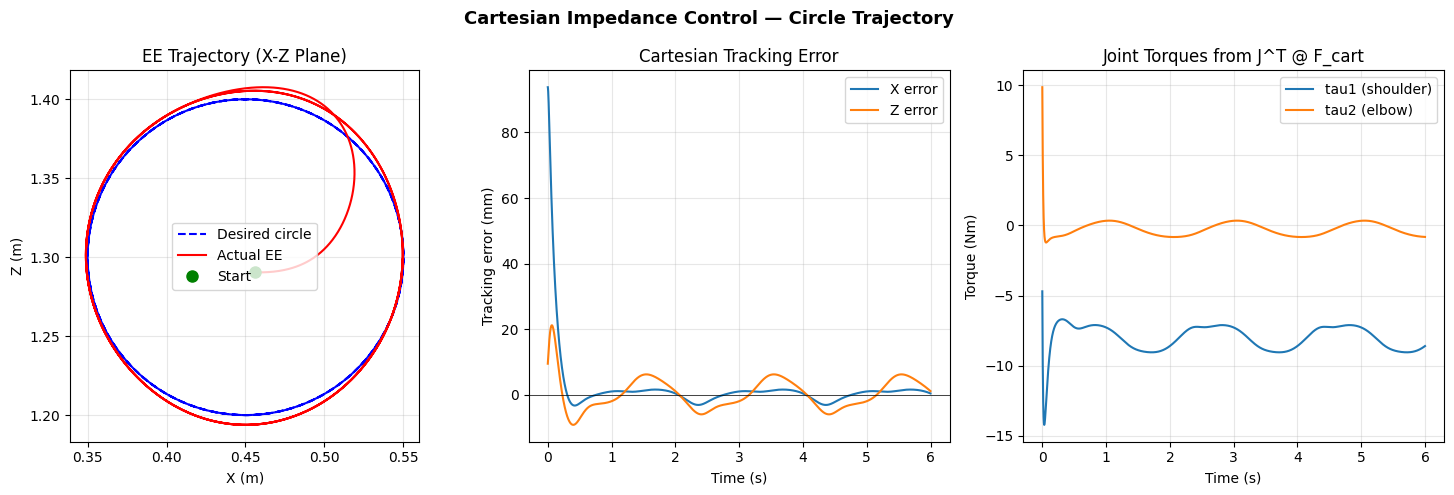

Figure saved.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Plot 1: EE trajectory (X-Z plane) ----
ax = axes[0]
ax.plot(ee_des_log[:, 0], ee_des_log[:, 1], 'b--', lw=1.5, label='Desired circle')
ax.plot(ee_log[:, 0],     ee_log[:, 1],     'r-',  lw=1.5, label='Actual EE')
ax.plot(ee_log[0, 0],     ee_log[0, 1],     'go',  ms=8,   label='Start')
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title('EE Trajectory (X-Z Plane)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Plot 2: Tracking error time series ----
ax = axes[1]
ax.plot(t_log, err_log[:, 0] * 1000, label='X error')
ax.plot(t_log, err_log[:, 1] * 1000, label='Z error')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Tracking error (mm)')
ax.set_title('Cartesian Tracking Error')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)

# ---- Plot 3: Joint torques ----
ax = axes[2]
ax.plot(t_log, tau_log[:, 0], label='tau1 (shoulder)')
ax.plot(t_log, tau_log[:, 1], label='tau2 (elbow)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (Nm)')
ax.set_title('Joint Torques from J^T @ F_cart')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Cartesian Impedance Control — Circle Trajectory', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tempfile.gettempdir(), 'nb4_cartesian_demo.png'), dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Stiffness Ellipse Visualization

### Theory: The Geometry of Cartesian Stiffness

The Cartesian stiffness matrix $\mathbf{K}_{cart} \in \mathbb{R}^{2\times2}$ is symmetric positive-definite. Its eigendecomposition reveals the **principal directions of stiffness**:

$$\mathbf{K}_{cart} = \mathbf{V}\, \boldsymbol{\Lambda}\, \mathbf{V}^T$$

where $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \lambda_2)$ and $\mathbf{V}$ contains the eigenvectors.

The **stiffness ellipse** has semi-axes $a_i = \text{scale} \times \sqrt{\lambda_i}$ oriented along the eigenvectors. A larger eigenvalue means more stiffness (less compliance) in that direction.

**Key insight:** Even though $\mathbf{K}_{cart}$ is constant, the **effective** Cartesian stiffness experienced at the joints varies with arm configuration. The stiffness ellipse plotted at the end-effector shows the *task-space* stiffness, which remains constant by design — unlike the joint torques required to maintain it, which depend on $\mathbf{J}(\mathbf{q})$.

In [ ]:
def plot_stiffness_ellipse(ax, K_cart, center, scale=0.05, **kwargs):
    """
    Plot the stiffness ellipse for a 2x2 Cartesian stiffness matrix.

    Semi-axes = scale * sqrt(eigenvalue), oriented along eigenvectors.
    Larger eigenvalue (stiffer) = longer axis.

    Args:
      K_cart: (2,2) symmetric positive-definite stiffness matrix
      center: (x, z) position in task space
      scale:  scaling factor for visual size
    """
    eigenvalues, eigenvectors = np.linalg.eigh(K_cart)   # eigh for symmetric matrices
    # Semi-axis lengths: proportional to sqrt(eigenvalue)
    a = scale * np.sqrt(eigenvalues[1])   # major axis (larger eigenvalue)
    b = scale * np.sqrt(eigenvalues[0])   # minor axis (smaller eigenvalue)
    # Rotation angle: angle of the principal eigenvector from the X axis
    angle = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))
    ellipse = Ellipse(xy=center, width=2*a, height=2*b, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse, eigenvalues


print("plot_stiffness_ellipse defined")

# Arm configurations to visualize
arm_configs = [
    np.array([0.0,       0.0]),         # both links horizontal (arm extended)
    np.array([np.pi/6,  -np.pi/4]),     # 30 deg shoulder, -45 deg elbow
    np.array([np.pi/4,  -np.pi/3]),     # 45 deg shoulder, -60 deg elbow
    np.array([np.pi/3,  -np.pi/2]),     # 60 deg shoulder, -90 deg elbow
    np.array([np.pi/2,  -np.pi/4]),     # 90 deg shoulder, -45 deg elbow
    np.array([np.pi/4,   np.pi/6]),     # 45 deg shoulder, +30 deg elbow (elbow up)
]
config_labels = [
    'q=[0°, 0°]', 'q=[30°,-45°]', 'q=[45°,-60°]',
    'q=[60°,-90°]', 'q=[90°,-45°]', 'q=[45°,+30°]'
]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(arm_configs)))

# Anisotropic stiffness to make ellipse shape clear
K_ellipse = np.array([[600.0,  50.0],
                       [ 50.0, 200.0]])  # off-diagonal coupling

print(f"K_ellipse eigenvalues: {np.sort(np.linalg.eigvalsh(K_ellipse))[::-1]}")
print(f"K_ellipse is positive definite: {np.all(np.linalg.eigvalsh(K_ellipse) > 0)}")

## Summary

### What We Built

| Concept | Implementation | Key Insight |
|---------|---------------|-------------|
| Jacobian via MuJoCo | `mj_jacSite(model, data, jacp, jacr, ee_site_id)` | MuJoCo computes it efficiently; no manual derivation |
| EE velocity | `dx = J_xz @ dq` | Velocity kinematics — primal relationship |
| Force mapping | `tau = J_xz.T @ F_cart` | Force kinematics — dual relationship via virtual work |
| Cartesian stiffness | `F = K_cart @ (x_d - x)` | Stiffness specified in task space, not joint space |

### The Jacobian Transpose in Three Words

> **Velocity → force dual**: If $\dot{\mathbf{x}} = \mathbf{J}\dot{\mathbf{q}}$ maps velocities, then $\boldsymbol{\tau} = \mathbf{J}^T\mathbf{F}$ maps forces. Same Jacobian, opposite transpose, opposite direction of energy flow.

## What's Next: Notebook 5 — Tendon Actuation

We've now covered impedance control from **scalar** (Notebook 1 mass-spring-damper) through **1-DOF** (Notebook 2 pendulum) through **multi-DOF joint-space** (Notebook 3 2-DOF arm) to **Cartesian task-space** (Notebook 4 Jacobian transpose).

Next: What happens when the actuator is not a motor but a **tendon**? Tendons can only pull (tension-only), creating asymmetric actuation. Notebook 5 introduces MuJoCo's tendon API and the capstone model — a finger mechanism driven by tendons, where impedance control must account for the tendon routing geometry.